In [2]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

## Ejercicio 12 - Problema de los tres cuerpos.

Es problema de los tres cuerpos es uno de los problemas más desafiante de la mecánica celeste.

Tres estrellas, en un espacio por lo demás vacío, están inicialmente en reposo, con las siguientes masas y posiciones, en unidades arbitrarias:


|     |Mass | $x$ | $y$ |
| :-: | :-: | :-: | :-: |
Star 1 | 150 | 3 | 1 |
Star 2 | 200 | $-1$ | $-2$ |
Star 3 | 250 | $-1$ | 1 |


(Todas las coordenadas $z$ son cero, por lo que las tres estrellas se encuentran en el plano $xy$).


1. Demostrar que la ecuación de movimiento que rige la posición $\vec{r}_1$ de la primera estrella es
  
    $${\text{d}^2\vec{r}_1\over\text{d} t^2}= Gm_2{\vec{r}_2-\vec{r}_1\over|\vec{r}_2-\vec{r}_1|^3}+ Gm_3{\vec{r}_3-\vec{r}_1\over|\vec{r}_3-\vec{r}_1|^3}$$

    y derivar dos ecuaciones similares para las posiciones $\vec{r}_2$ y $\vec{r}_3$ de las otras dos estrellas.  A continuación, convirtamos las tres ecuaciones de segundo orden en seis ecuaciones de primer orden equivalentes, utilizando las técnicas que hemos aprendido.


2. Trabajando en unidades donde $G=1$, escribe un programa que resuelva tus ecuaciones y así calcular el movimiento de las estrellas desde $t=0$ hasta $t=2$.  Hacer un gráfico que muestre las trayectorias de las tres estrellas.


3. Modificar el programa para hacer una animación del movimiento en la pantalla desde $t=0$ hasta $t=10$.  Es conveniente hacer que las tres estrellas sean de diferentes tamaños o colores (o ambos) para que se pueda saber cuál es cada una.


**Ayuda:**

- Crear una animación con un tamaño de paso adaptable puede ser un reto ya que los pasos no corresponden todos a la misma cantidad de tiempo real.  Lo más sencillo es ignorar los diferentes tamaños de los pasos y hacer una animación como si todos fueran iguales, actualizando las posiciones de las estrellas en la pantalla a cada paso o cada varios pasos.  Esto le dará una visualización razonable del movimiento, pero se verá un poco extraño porque las estrellas se ralentizarán, en lugar de acelerarse, cuando se acerquen a medida que se acercan, porque el cálculo adaptativo tomará automáticamente más pasos en esta región.


- Una mejor solución es variar la velocidad de fotogramas de la animación para que los fotogramas se ejecuten proporcionalmente más rápido cuando $h$ sea menor, lo que significa que la velocidad de fotogramas debe ser igual a $C/h$ para una constante $C$.  Se puede lograr esto usando la función \verb de vpython para establecer una velocidad de fotogramas diferente en cada paso, igual a $C/h$.  Si hace esto, es una buena idea no dejar que el valor de $h$ crezca demasiado grande, o la animación dará algunos saltos grandes que se verán desiguales en en la pantalla.  Inserte líneas de programa adicionales para asegurar que $h$ nunca exceda un valor $h_\textrm{max}$ que usted elija.  Valores para las constantes de alrededor de $C=0,1$ y $h_\textrm{max}=10^{-3}$ parecen dar resultados razonables.

---

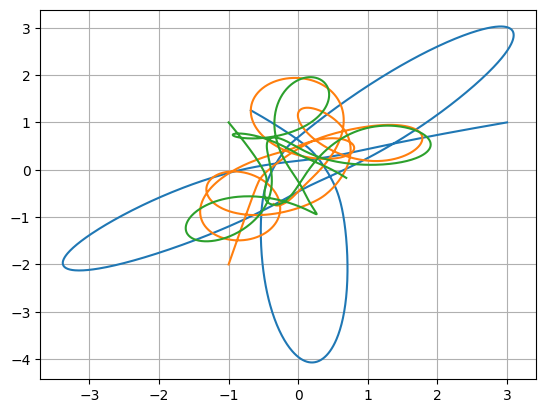

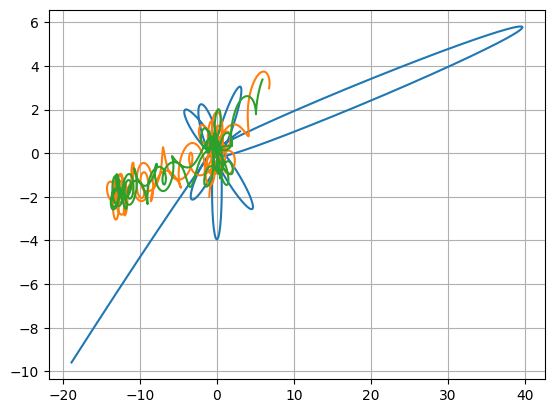

In [3]:
m1, m2, m3 = 150, 200, 250
G = 1

r10 = np.array([3, 1], float)
r20 = np.array([-1, -2], float)
r30 = np.array([-1, 1], float)
v10 = np.array([0, 0], float)
v20 = np.array([0, 0], float)
v30 = np.array([0, 0], float)

r = np.array([r10, r20, r30, v10, v20, v30])

def norm_sq(v):
    return v[0]**2 + v[1]**2

def F(r, t):
    r1, r2, r3 = r[0], r[1], r[2]
    v1, v2, v3 = r[3], r[4], r[5]

    fr1, fr2, fr3 = v1, v2, v3

    fv1 = G * (m2 * (r2 - r1) / norm_sq(r2 - r1) + m3 * (r3 - r1) / norm_sq(r3 - r1))
    fv2 = G * (m1 * (r1 - r2) / norm_sq(r1 - r2) + m3 * (r3 - r2) / norm_sq(r3 - r2))
    fv3 = G * (m1 * (r1 - r3) / norm_sq(r1 - r3) + m2 * (r2 - r3) / norm_sq(r2 - r3))

    return np.array([fr1, fr2, fr3, fv1, fv2, fv3], float)

def three_body(F, a, b, N, r):
    h = (b - a) / N
    time = np.linspace(a, b, N)
    r1p = np.zeros([2, len(time)], float)
    r2p = np.zeros([2, len(time)], float)
    r3p = np.zeros([2, len(time)], float)
    r = np.array(r, float)

    for i, t in enumerate(time):
        r1p[:, i] = r[0]
        r2p[:, i] = r[1]
        r3p[:, i] = r[2]

        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return time, r1p, r2p, r3p

t, r1p, r2p, r3p = three_body(F, 0, 2, 1000, r)
plt.plot(r1p[0, :], r1p[1, :])
plt.plot(r2p[0, :], r2p[1, :])
plt.plot(r3p[0, :], r3p[1, :])
plt.grid()
plt.show()

t, r1p, r2p, r3p = three_body(F, 0, 10, 1000, r)
plt.plot(r1p[0, :], r1p[1, :])
plt.plot(r2p[0, :], r2p[1, :])
plt.plot(r3p[0, :], r3p[1, :])
plt.grid()
plt.show()